# Iris: correlacion y componentes principales

Objetivo: explorar relaciones entre variables y reducir dimensionalidad con PCA.

## 1) Librerias

In [1]:
!pip install pandas matplotlib seaborn scikit-learn

In [2]:
# Datos
import pandas as pd

In [3]:
# Graficos base
import matplotlib.pyplot as plt

In [4]:
# Graficos estadisticos
import seaborn as sns

In [5]:
# Estandarizacion
from sklearn.preprocessing import StandardScaler

In [6]:
# PCA
from sklearn.decomposition import PCA

In [7]:
# Estilo visual
sns.set_theme(style="whitegrid")

## 2) Cargar datos

In [8]:
# Leer archivo
iris_data = pd.read_csv("iris.csv")

In [9]:
# Variable de clase como categoria
iris_data["variety"] = iris_data["variety"].astype("category")

In [10]:
# Vista rapida
iris_data.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [11]:
# Resumen
iris_data.describe(include="all")

,sepal.length,sepal.width,petal.length,petal.width,variety
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,Setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.057333,3.758000,1.199333,NaN
std,0.828066,0.435866,1.765298,0.762238,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


## 3) Correlacion entre variables numericas

In [12]:
# Seleccionar columnas numericas
num_data = iris_data.select_dtypes(include=["number"])

In [13]:
# Matriz de correlacion
cor_mat = num_data.corr().round(2)

In [14]:
# Ver matriz
cor_mat

,sepal.length,sepal.width,petal.length,petal.width
sepal.length,1.00,-0.12,0.87,0.82
sepal.width,-0.12,1.00,-0.43,-0.37
petal.length,0.87,-0.43,1.00,0.96
petal.width,0.82,-0.37,0.96,1.00


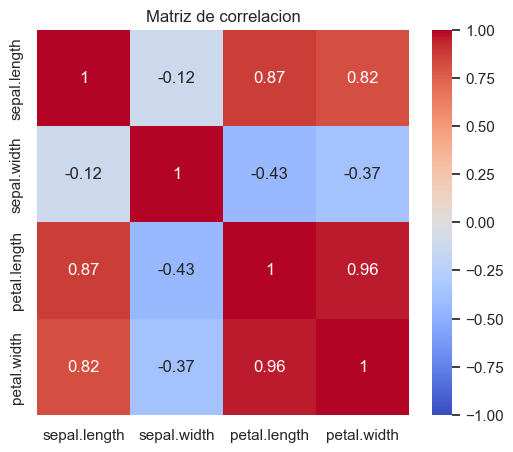

In [15]:
# Heatmap de correlaciones
plt.figure(figsize=(6, 5))
sns.heatmap(cor_mat, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlacion")
plt.show()

## 4) Visualizacion 3D de variables originales

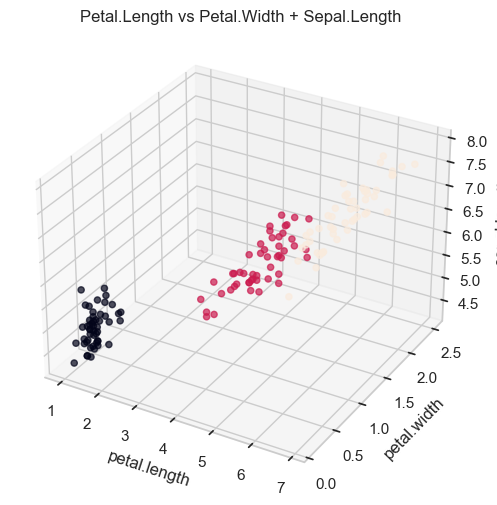

In [16]:
# Dispersión 3D simple
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(iris_data["petal.length"], iris_data["petal.width"], iris_data["sepal.length"], c=iris_data["variety"].cat.codes, alpha=0.7)
ax.set_title("Petal.Length vs Petal.Width + Sepal.Length")
ax.set_xlabel("petal.length")
ax.set_ylabel("petal.width")
ax.set_zlabel("sepal.length")
plt.show()

## 5) Preparar datos para PCA

In [17]:
# Matriz X (solo numericas)
X = num_data.copy()

In [18]:
# Estandarizar variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 6) Ajustar PCA

In [19]:
# Crear modelo
pca = PCA()

In [20]:
# Ajustar modelo
pca.fit(X_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [21]:
# Varianza explicada
pca.explained_variance_ratio_

array([0.72962445, 0.22850762, 0.03668922, 0.00517871])

In [22]:
# Varianza acumulada
pca.explained_variance_ratio_.cumsum()

array([0.72962445, 0.95813207, 0.99482129, 1.        ])

## 7) Scree plot

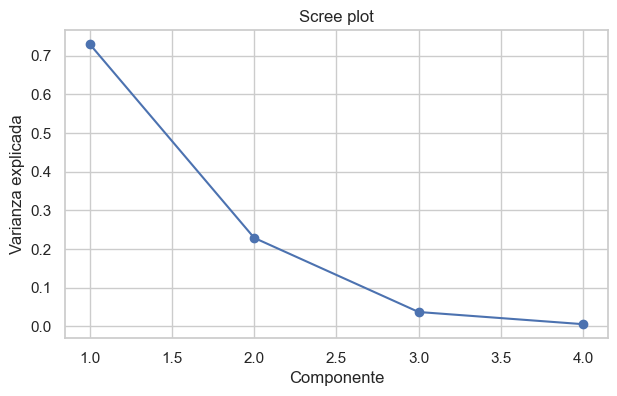

In [23]:
# Grafico de varianza por componente
componentes = range(1, len(pca.explained_variance_ratio_) + 1)
plt.figure(figsize=(7, 4))
plt.plot(componentes, pca.explained_variance_ratio_, marker="o")
plt.title("Scree plot")
plt.xlabel("Componente")
plt.ylabel("Varianza explicada")
plt.show()

## 8) Contribucion de variables (loadings)

In [24]:
# Cargas por componente
loadings = pd.DataFrame(pca.components_.T, index=X.columns, columns=["PC1", "PC2", "PC3", "PC4"])

In [25]:
# Ver loadings
loadings

,PC1,PC2,PC3,PC4
sepal.length,0.521066,0.377418,0.719566,-0.261286
sepal.width,-0.269347,0.923296,-0.244382,0.123510
petal.length,0.580413,0.024492,-0.142126,0.801449
petal.width,0.564857,0.066942,-0.634273,-0.523597


In [26]:
# Contribuciones absolutas en PC1
contrib_pc1 = loadings["PC1"].abs().sort_values(ascending=False)
contrib_pc1

petal.length    0.580413
petal.width     0.564857
sepal.length    0.521066
sepal.width     0.269347
Name: PC1, dtype: float64

In [27]:
# Contribuciones absolutas en PC2
contrib_pc2 = loadings["PC2"].abs().sort_values(ascending=False)
contrib_pc2

sepal.width     0.923296
sepal.length    0.377418
petal.width     0.066942
petal.length    0.024492
Name: PC2, dtype: float64

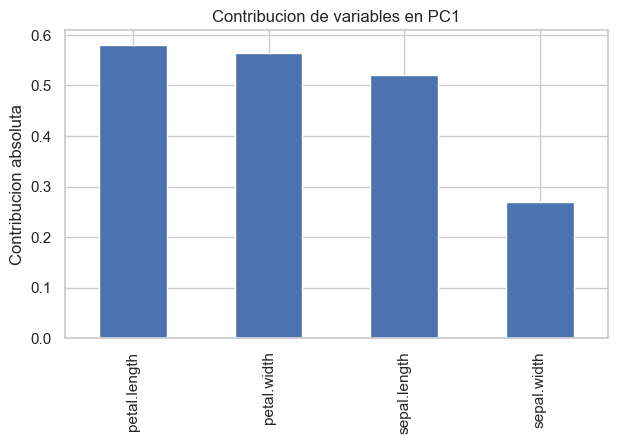

In [28]:
# Grafico contribucion PC1
plt.figure(figsize=(7, 4))
contrib_pc1.plot(kind="bar")
plt.title("Contribucion de variables en PC1")
plt.ylabel("Contribucion absoluta")
plt.show()

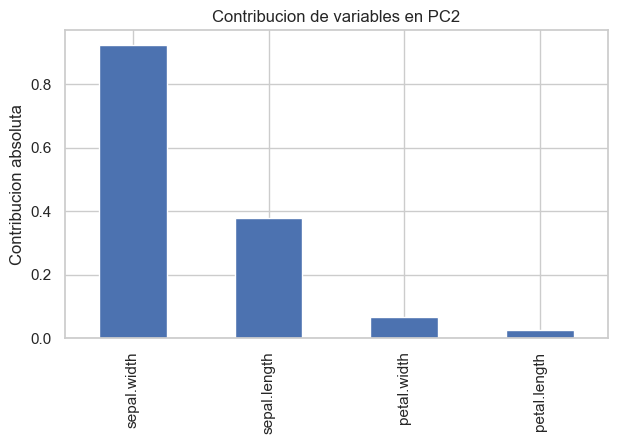

In [29]:
# Grafico contribucion PC2
plt.figure(figsize=(7, 4))
contrib_pc2.plot(kind="bar")
plt.title("Contribucion de variables en PC2")
plt.ylabel("Contribucion absoluta")
plt.show()

## 9) Proyecciones de observaciones

In [30]:
# Coordenadas PCA
scores = pca.transform(X_scaled)

In [31]:
# Tabla de componentes
scores_df = pd.DataFrame(scores, columns=["PC1", "PC2", "PC3", "PC4"])

In [32]:
# Agregar clase
scores_df["variety"] = iris_data["variety"].values

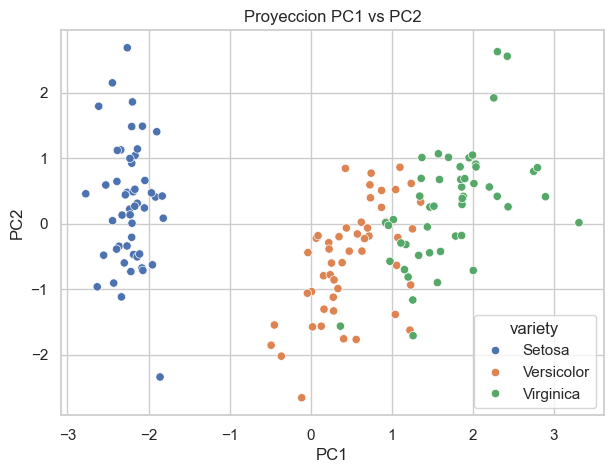

In [33]:
# PC1 vs PC2
plt.figure(figsize=(7, 5))
sns.scatterplot(data=scores_df, x="PC1", y="PC2", hue="variety")
plt.title("Proyeccion PC1 vs PC2")
plt.show()

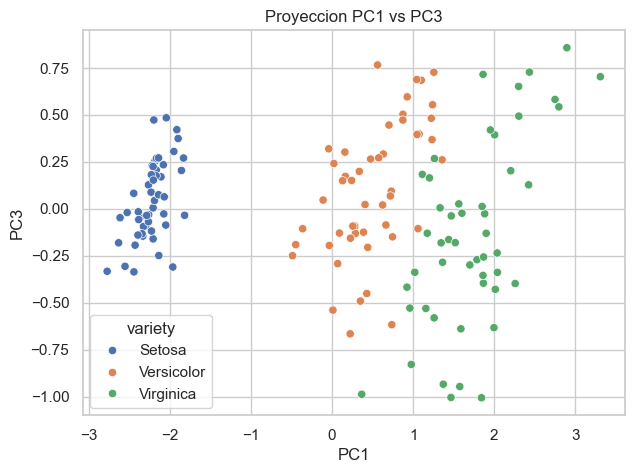

In [34]:
# PC1 vs PC3
plt.figure(figsize=(7, 5))
sns.scatterplot(data=scores_df, x="PC1", y="PC3", hue="variety")
plt.title("Proyeccion PC1 vs PC3")
plt.show()

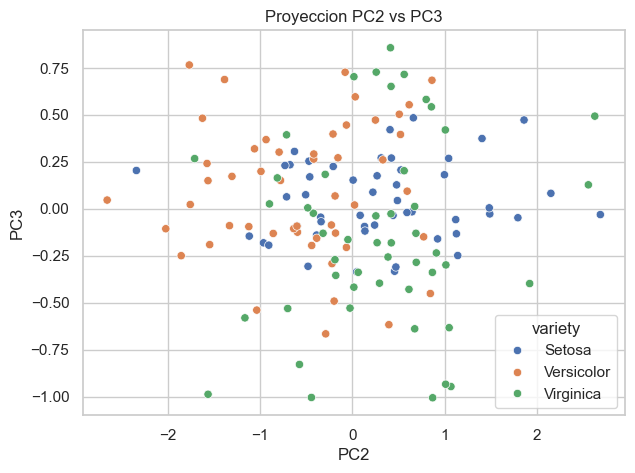

In [35]:
# PC2 vs PC3
plt.figure(figsize=(7, 5))
sns.scatterplot(data=scores_df, x="PC2", y="PC3", hue="variety")
plt.title("Proyeccion PC2 vs PC3")
plt.show()

## 10) Densidad por componentes

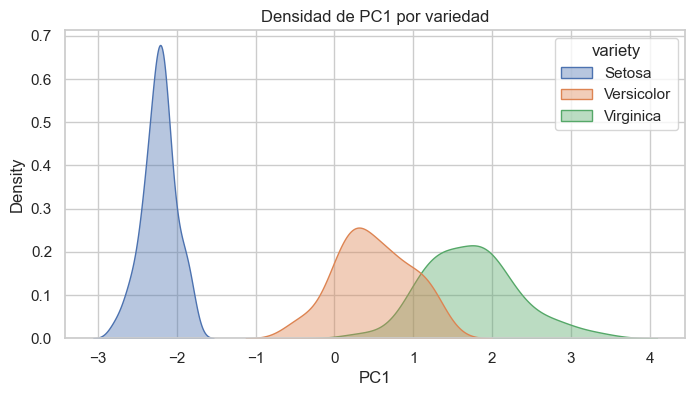

In [36]:
# Densidad de PC1 por clase
plt.figure(figsize=(8, 4))
sns.kdeplot(data=scores_df, x="PC1", hue="variety", fill=True, alpha=0.4)
plt.title("Densidad de PC1 por variedad")
plt.show()

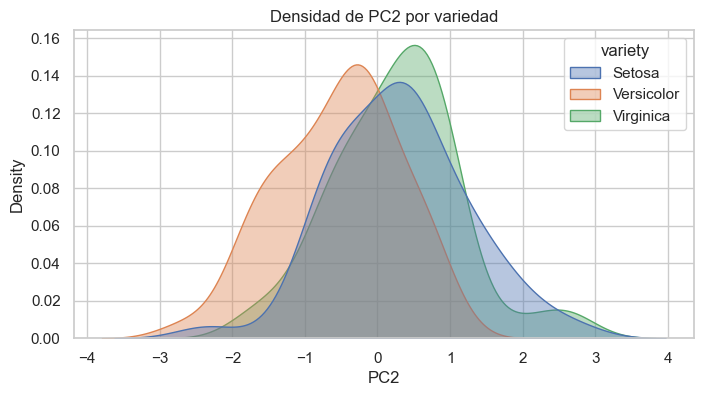

In [37]:
# Densidad de PC2 por clase
plt.figure(figsize=(8, 4))
sns.kdeplot(data=scores_df, x="PC2", hue="variety", fill=True, alpha=0.4)
plt.title("Densidad de PC2 por variedad")
plt.show()

## 11) Vista 3D en el espacio PCA

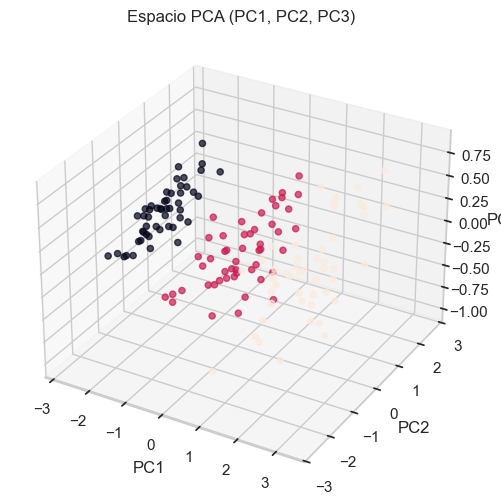

In [38]:
# Dispersión 3D de PC1, PC2, PC3
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(scores_df["PC1"], scores_df["PC2"], scores_df["PC3"], c=iris_data["variety"].cat.codes, alpha=0.7)
ax.set_title("Espacio PCA (PC1, PC2, PC3)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.show()

## 12) Biplot

En este gráfico vemos al mismo tiempo:
- las observaciones proyectadas en PC1 y PC2,
- y la dirección/aporte de cada variable original (flechas).

In [ ]:
# Biplot PC1 vs PC2 (puntos + flechas de variables)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=scores_df, x="PC1", y="PC2", hue="variety", alpha=0.7)

# Escala visual para que las flechas se vean sobre la nube de puntos
escala = 3
for i in range(len(X.columns)):
    x_flecha = loadings.iloc[i, 0] * escala
    y_flecha = loadings.iloc[i, 1] * escala
    plt.arrow(0, 0, x_flecha, y_flecha, color="black", alpha=0.8, head_width=0.06)
    plt.text(x_flecha * 1.1, y_flecha * 1.1, X.columns[i], color="black")

plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.title("Biplot: observaciones y variables en PC1-PC2")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()
